In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Create synthetic temperature dataset
np.random.seed(42)

n = 1000
temperature = np.random.normal(loc=28, scale=1.5, size=n)
heat_stress = np.random.normal(loc=4, scale=2, size=n)

# Create bleaching probability rule (fake but realistic)
bleaching = (temperature > 29.5) & (heat_stress > 5)
bleaching = bleaching.astype(int)

df = pd.DataFrame({
    "temperature": temperature,
    "heat_stress": heat_stress,
    "bleaching": bleaching
})

X = df[["temperature", "heat_stress"]]
y = df["bleaching"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = xgb.XGBClassifier()
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, preds))

AttributeError: module 'pandas' has no attribute 'util'

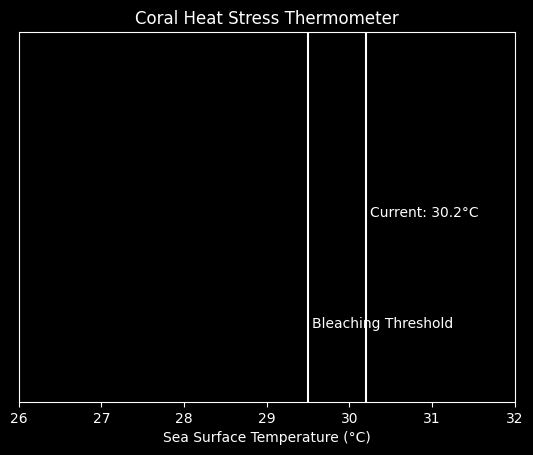

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated current sea surface temperature
current_temp = 30.2  # try changing this

# Define bleaching threshold
threshold = 29.5

# Create visual scale
temps = np.linspace(26, 32, 100)

plt.figure()

plt.axvline(current_temp)
plt.axvline(threshold)

plt.text(current_temp + 0.05, 0.5, f"Current: {current_temp}°C")
plt.text(threshold + 0.05, 0.2, "Bleaching Threshold")

plt.xlim(26, 32)
plt.ylim(0, 1)
plt.yticks([])
plt.xlabel("Sea Surface Temperature (°C)")
plt.title("Coral Heat Stress Thermometer")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

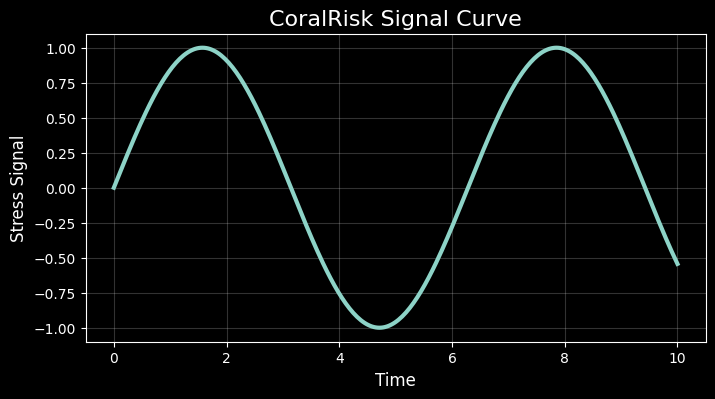

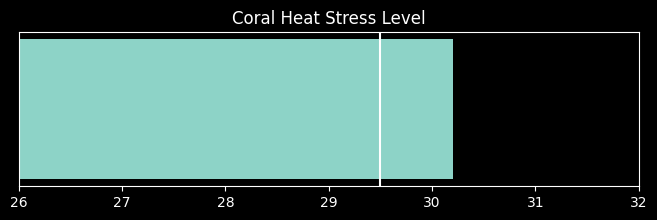

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(0, 10, 300)
y = np.sin(x)

# Style
plt.style.use("dark_background")

plt.figure(figsize=(8, 4))
plt.plot(x, y, linewidth=3)

plt.title("CoralRisk Signal Curve", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Stress Signal", fontsize=12)

plt.grid(alpha=0.2)

plt.show()

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

current_temp = 30.2
threshold = 29.5

plt.figure(figsize=(8,2))

plt.barh(0, current_temp, height=0.5)
plt.axvline(threshold)

plt.xlim(26, 32)
plt.yticks([])
plt.title("Coral Heat Stress Level")

plt.show()

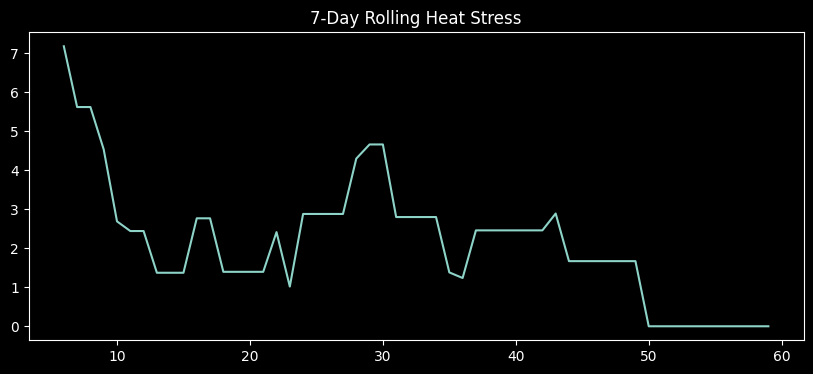

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create fake daily temperature data
np.random.seed(0)

days = 60
baseline = 29.0
temperature = baseline + np.random.normal(0.5, 0.6, days)

df = pd.DataFrame({
    "day": range(days),
    "temperature": temperature
})

# Calculate anomaly
df["anomaly"] = df["temperature"] - baseline

# Only count stress above 1°C
df["heat_stress"] = df["anomaly"].apply(lambda x: x if x > 1 else 0)

# Rolling 7-day cumulative stress
df["rolling_stress"] = df["heat_stress"].rolling(window=7).sum()

df.head()

plt.figure(figsize=(10,4))
plt.plot(df["rolling_stress"])
plt.title("7-Day Rolling Heat Stress")
plt.show()


In [ ]:
df["bleaching_risk"] = (df["rolling_stress"] > 4).astype(int)

df[["rolling_stress", "bleaching_risk"]].tail(10)

,rolling_stress,bleaching_risk
50,0.0,0
51,0.0,0
52,0.0,0
53,0.0,0
54,0.0,0
55,0.0,0
56,0.0,0
57,0.0,0
58,0.0,0
59,0.0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# Features (inputs)
X = df[["temperature", "anomaly", "heat_stress", "rolling_stress"]]

# Target (what we predict)
y = df["bleaching_risk"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = XGBClassifier()

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: nan


/Users/shiyalilith/miniconda3/envs/coral-ai/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
df["bleaching_risk"].value_counts()

bleaching_risk
0    53
1     7
Name: count, dtype: int64

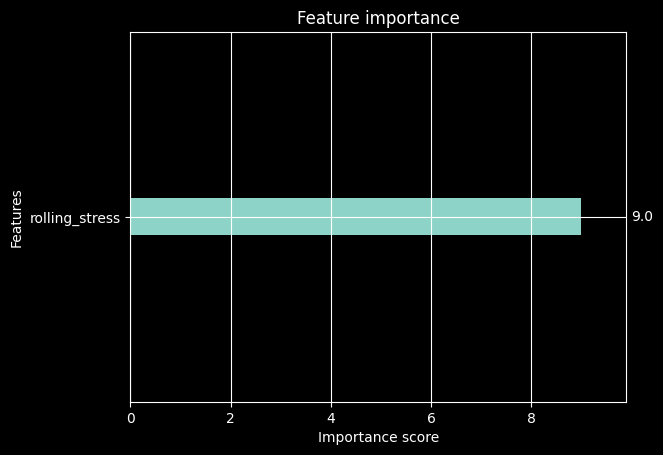

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model)
plt.show()

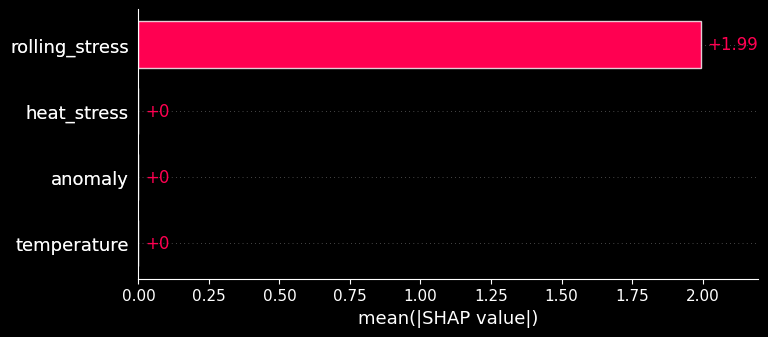

In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X)

shap.plots.bar(shap_values)

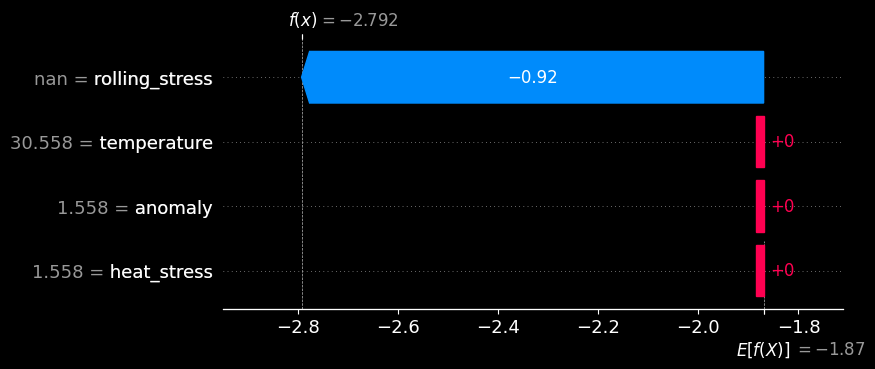

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
import pandas as pd

df_real = pd.read_csv("data/raw/realistic_ocean_climate_dataset.csv")
df_real.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [ ]:
df_real.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                500 non-null    str    
 1   Location            500 non-null    str    
 2   Latitude            500 non-null    float64
 3   Longitude           500 non-null    float64
 4   SST (°C)            500 non-null    float64
 5   pH Level            500 non-null    float64
 6   Bleaching Severity  350 non-null    str    
 7   Species Observed    500 non-null    int64  
 8   Marine Heatwave     500 non-null    bool   
dtypes: bool(1), float64(4), int64(1), str(3)
memory usage: 31.9 KB


In [ ]:
df_real["Marine Heatwave"].value_counts()

Marine Heatwave
False    427
True      73
Name: count, dtype: int64

In [ ]:
df_real = df_real.rename(columns={"SST (°C)": "SST"})

# Convert Marine Heatwave to integer
df_real["Marine Heatwave"] = df_real["Marine Heatwave"].astype(int)

# Convert Date to datetime
df_real["Date"] = pd.to_datetime(df_real["Date"])

df_real.head()

from sklearn.model_selection import train_test_split

X = df_real[["SST", "pH Level", "Latitude", "Longitude", "Species Observed"]]
y = df_real["Marine Heatwave"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 1.0


In [ ]:
df_real.groupby("Marine Heatwave")["SST"].describe()

,count,mean,std,min,25%,50%,75%,max
Marine Heatwave,,,,,,,,
0,427.0,28.142600,1.114886,23.64,27.42,28.27,29.005,29.98
1,73.0,30.845342,0.629012,30.01,30.29,30.75,31.200,33.21


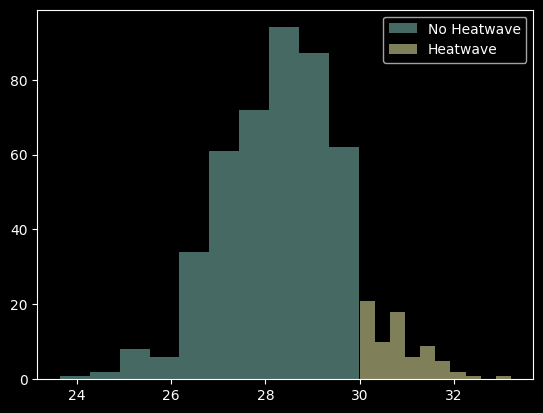

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_real[df_real["Marine Heatwave"]==0]["SST"], alpha=0.5, label="No Heatwave")
plt.hist(df_real[df_real["Marine Heatwave"]==1]["SST"], alpha=0.5, label="Heatwave")
plt.legend()
plt.show()

In [ ]:
df_noisy = df_real.copy()
df_noisy["SST"] += np.random.normal(0, 0.3, len(df_noisy))


In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, preds))

ROC-AUC: 1.0


In [4]:
print(X.columns)

Index(['temperature', 'heat_stress'], dtype='str')


In [5]:
import numpy as np

y_shuffled = np.random.permutation(y)

model.fit(X_train, y_shuffled[:len(X_train)])
preds = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print("ROC-AUC with shuffled labels:", roc_auc_score(y_test, preds))

AttributeError: module 'pandas' has no attribute 'util'

In [6]:
pip install --upgrade xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr

ds = xr.open_dataset("data/raw/noaaSSTcoralData.nc")
ds

<xarray.Dataset> Size: 6kB
Dimensions:       (time: 366, latitude: 1, longitude: 1)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2024-01-01T12:00:00 ... 2024-12-3...
  * latitude      (latitude) float32 4B -17.98
  * longitude     (longitude) float32 4B 147.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 3kB ...
Attributes: (12/68)
    acknowledgement:                  NOAA Coral Reef Watch Program
    cdm_data_type:                    Grid
    comment:                          This product is designed to improve on ...
    contributor_name:                 NOAA Coral Reef Watch Program
    contributor_role:                 Collecting source data and deriving pro...
    Conventions:                      CF-1.6, ACDD-1.3, COARDS
    ...                               ...
    time_coverage_duration:           P1D
    time_coverage_end:                2024-12-31T12:00:00Z
    time_coverage_resolution:         P1D
    time_coverage_start:              2024-01-01T12:00:00Z
    title:                            Sea Surface Temperature, NOAA Coral Ree...
    Westernmost_Easting:              147.025

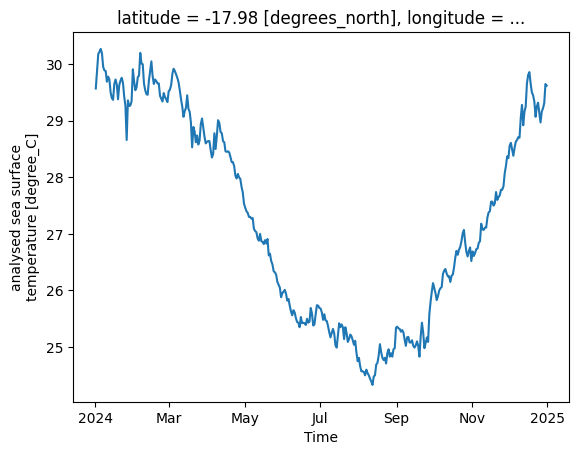

In [3]:
sst = ds["analysed_sst"].squeeze()

sst

sst.plot()


In [4]:
import pandas as pd

df = sst.to_dataframe().reset_index()

df.head()

,time,latitude,longitude,analysed_sst
0,2024-01-01 12:00:00,-17.975,147.024994,29.57
1,2024-01-02 12:00:00,-17.975,147.024994,29.88
2,2024-01-03 12:00:00,-17.975,147.024994,30.18
3,2024-01-04 12:00:00,-17.975,147.024994,30.22
4,2024-01-05 12:00:00,-17.975,147.024994,30.27


In [5]:
df = df.rename(columns={"analysed_sst": "SST"})
df = df[["time", "SST"]]
df.head()

,time,SST
0,2024-01-01 12:00:00,29.57
1,2024-01-02 12:00:00,29.88
2,2024-01-03 12:00:00,30.18
3,2024-01-04 12:00:00,30.22
4,2024-01-05 12:00:00,30.27


In [6]:
baseline = df["SST"].mean()

df["anomaly"] = df["SST"] - baseline

In [7]:
df["heat_stress"] = df["anomaly"].apply(lambda x: x if x > 1 else 0)

In [8]:
df["rolling_stress"] = df["heat_stress"].rolling(window=84).sum()

<Axes: >

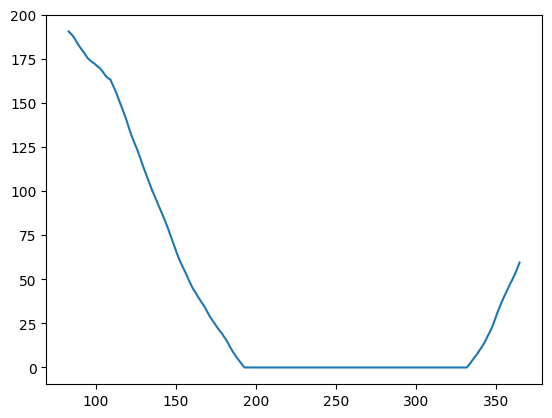

In [9]:
df["rolling_stress"].plot()

In [1]:
# Cell 1: load NOAA NetCDF
from pathlib import Path
import xarray as xr

nc_path = Path("data/raw/noaaSSTcoralData.nc")
if not nc_path.exists():
    raise FileNotFoundError(f"Missing file: {nc_path.resolve()}")

ds = xr.open_dataset(nc_path)
ds


<xarray.Dataset> Size: 6kB
Dimensions:       (time: 366, latitude: 1, longitude: 1)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2024-01-01T12:00:00 ... 2024-12-3...
  * latitude      (latitude) float32 4B -17.98
  * longitude     (longitude) float32 4B 147.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 3kB ...
Attributes: (12/68)
    acknowledgement:                  NOAA Coral Reef Watch Program
    cdm_data_type:                    Grid
    comment:                          This product is designed to improve on ...
    contributor_name:                 NOAA Coral Reef Watch Program
    contributor_role:                 Collecting source data and deriving pro...
    Conventions:                      CF-1.6, ACDD-1.3, COARDS
    ...                               ...
    time_coverage_duration:           P1D
    time_coverage_end:                2024-12-31T12:00:00Z
    time_coverage_resolution:         P1D
    time_coverage_start:              2024-01-01T12:00:00Z
    title:                            Sea Surface Temperature, NOAA Coral Ree...
    Westernmost_Easting:              147.025

In [2]:
# Cell 2: quick inspect
print(ds)
print("dims:", dict(ds.sizes))
print("vars:", list(ds.data_vars))


<xarray.Dataset> Size: 6kB
Dimensions:       (time: 366, latitude: 1, longitude: 1)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2024-01-01T12:00:00 ... 2024-12-3...
  * latitude      (latitude) float32 4B -17.98
  * longitude     (longitude) float32 4B 147.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 3kB ...
Attributes: (12/68)
    acknowledgement:                  NOAA Coral Reef Watch Program
    cdm_data_type:                    Grid
    comment:                          This product is designed to improve on ...
    contributor_name:                 NOAA Coral Reef Watch Program
    contributor_role:                 Collecting source data and deriving pro...
    Conventions:                      CF-1.6, ACDD-1.3, COARDS
    ...                               ...
    time_coverage_duration:           P1D
    time_coverage_end:                2024-12-31T12:00:00Z
    time_coverage_resolution:         P1D
    time_coverage_start:              202

In [3]:
# Cell 3: extract SST series
sst = ds["analysed_sst"].squeeze()  # removes 1x1 lat/lon if present
sst_df = sst.to_dataframe().reset_index()
sst_df.head()


,time,latitude,longitude,analysed_sst
0,2024-01-01 12:00:00,-17.975,147.024994,29.57
1,2024-01-02 12:00:00,-17.975,147.024994,29.88
2,2024-01-03 12:00:00,-17.975,147.024994,30.18
3,2024-01-04 12:00:00,-17.975,147.024994,30.22
4,2024-01-05 12:00:00,-17.975,147.024994,30.27


In [5]:
# Cell 4: cleanup df["future_stress"] = df["rolling_stress"].shift(-14)
df["risk_label"] = (df["future_stress"] > 4).astype(int)
ds.close()


NameError: name 'df' is not defined

In [6]:
df["SST_lag1"] = df["SST"].shift(1)
df["SST_lag7"] = df["SST"].shift(7)
df["SST_lag14"] = df["SST"].shift(14)

df = df.dropna()

NameError: name 'df' is not defined

In [7]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

X = df[["SST", "SST_lag1", "SST_lag7", "SST_lag14"]]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, preds))

NameError: name 'df' is not defined

In [5]:
import xarray as xr

url = (
    "https://coastwatch.noaa.gov/erddap/griddap/noaacrwsstDaily"
    "?analysed_sst[(2015-01-01T12:00:00Z):1:(2024-12-31T12:00:00Z)]"
    "[(-18):1:(-18)]"
    "[(147):1:(147)]"
)

ds = xr.open_dataset(url, engine="pydap")
ds

ModuleNotFoundError: No module named 'pydap'

In [6]:
import sys
print(sys.executable)

/Users/shiyalilith/miniconda3/envs/coral-ai/bin/python


In [7]:
!pip install pydap

  Using cached pydap-3.5.9-py3-none-any.whl.metadata (9.0 kB)
  Using cached requests_cache-1.3.1-py3-none-any.whl.metadata (9.4 kB)
  Using cached WebOb-1.8.9-py2.py3-none-any.whl.metadata (11 kB)
  Using cached cattrs-26.1.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached url_normalize-2.2.1-py3-none-any.whl.metadata (5.6 kB)
Using cached pydap-3.5.9-py3-none-any.whl (2.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 3.0 MB/s  0:00:02 eta 0:00:01
Using cached requests_cache-1.3.1-py3-none-any.whl (70 kB)
Using cached cattrs-26.1.0-py3-none-any.whl (73 kB)
Using cached url_normalize-2.2.1-py3-none-any.whl (14 kB)
Using cached WebOb-1.8.9-py2.py3-none-any.whl (115 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [pydap]32m5/6 [pydap]


In [1]:
import pydap
print("pydap installed")

pydap installed


In [2]:
import xarray as xr

url = (
    "https://coastwatch.noaa.gov/erddap/griddap/noaacrwsstDaily"
    "?analysed_sst[(2015-01-01T12:00:00Z):1:(2024-12-31T12:00:00Z)]"
    "[(-18):1:(-18)]"
    "[(147):1:(147)]"
)

ds = xr.open_dataset(url, engine="pydap")
ds

/Users/shiyalilith/miniconda3/envs/coral-ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/shiyalilith/miniconda3/envs/coral-ai/lib/python3.11/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


AttributeError: 'str' object has no attribute 'pop'

In [3]:
---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
Cell In[2], line 10
      1 import xarray as xr
      3 url = (
      4     "https://coastwatch.noaa.gov/erddap/griddap/noaacrwsstDaily"
      5     "?analysed_sst[(2015-01-01T12:00:00Z):1:(2024-12-31T12:00:00Z)]"
      6     "[(-18):1:(-18)]"
      7     "[(147):1:(147)]"
      8 )
---> 10 ds = xr.open_dataset(url, engine="pydap")
     11 ds

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/xarray/backends/api.py:607, in open_dataset(filename_or_obj, engine, chunks, cache, decode_cf, mask_and_scale, decode_times, decode_timedelta, use_cftime, concat_characters, decode_coords, drop_variables, create_default_indexes, inline_array, chunked_array_type, from_array_kwargs, backend_kwargs, **kwargs)
    595 decoders = _resolve_decoders_kwargs(
    596     decode_cf,
    597     open_backend_dataset_parameters=backend.open_dataset_parameters,
   (...)    603     decode_coords=decode_coords,
    604 )
    606 overwrite_encoded_chunks = kwargs.pop("overwrite_encoded_chunks", None)
--> 607 backend_ds = backend.open_dataset(
    608     filename_or_obj,
    609     drop_variables=drop_variables,
    610     **decoders,
    611     **kwargs,
    612 )
    613 ds = _dataset_from_backend_dataset(
    614     backend_ds,
    615     filename_or_obj,
   (...)    626     **kwargs,
    627 )
    628 return ds

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/xarray/backends/pydap_.py:279, in PydapBackendEntrypoint.open_dataset(self, filename_or_obj, mask_and_scale, decode_times, concat_characters, decode_coords, drop_variables, use_cftime, decode_timedelta, group, application, session, output_grid, timeout, verify, user_charset, checksums)
    257 def open_dataset(
    258     self,
    259     filename_or_obj: (
   (...)    277     checksums=True,
    278 ) -> Dataset:
--> 279     store = PydapDataStore.open(
    280         url=filename_or_obj,
    281         group=group,
    282         application=application,
    283         session=session,
    284         output_grid=output_grid,
    285         timeout=timeout,
    286         verify=verify,
    287         user_charset=user_charset,
    288         checksums=checksums,
    289     )
    290     store_entrypoint = StoreBackendEntrypoint()
    291     with close_on_error(store):

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/xarray/backends/pydap_.py:141, in PydapDataStore.open(cls, url, group, application, session, output_grid, timeout, verify, user_charset, checksums)
    130 kwargs = {
    131     "url": url,
    132     "application": application,
   (...)    137     "user_charset": user_charset,
    138 }
    139 if isinstance(url, str):
    140     # check uit begins with an acceptable scheme
--> 141     dataset = open_url(**kwargs)
    142 elif hasattr(url, "ds"):
    143     # pydap dataset
    144     dataset = url.ds

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/pydap/client.py:179, in open_url(url, application, session, output_grid, flat, timeout, verify, checksums, user_charset, protocol, batch, use_cache, session_kwargs, cache_kwargs, get_kwargs)
    172 if not session:
    173     session = create_session(
    174         use_cache=use_cache,
    175         session_kwargs=session_kwargs,
    176         cache_kwargs=cache_kwargs,
    177     )
--> 179 handler = DAPHandler(
    180     url,
    181     application,
    182     session,
    183     output_grid=output_grid,
    184     flat=flat,
    185     timeout=timeout,
    186     verify=verify,
    187     checksums=checksums,
    188     user_charset=user_charset,
    189     protocol=protocol,
    190     get_kwargs=get_kwargs,
    191 )
    192 dataset = handler.dataset
    193 dataset._session = session

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/pydap/handlers/dap.py:164, in DAPHandler.__init__(self, url, application, session, output_grid, flat, timeout, verify, checksums, user_charset, protocol, get_kwargs)
    162     self.base_url = urlunparse(arg)
    163     self.make_dataset()
--> 164 self.add_proxies()

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/pydap/handlers/dap.py:280, in DAPHandler.add_proxies(self)
    278     self.add_dap4_proxies()
    279 else:
--> 280     self.add_dap2_proxies()

File ~/miniconda3/envs/coral-ai/lib/python3.11/site-packages/pydap/handlers/dap.py:368, in DAPHandler.add_dap2_proxies(self)
    366 target = self.dataset
    367 while var:
--> 368     token, index = var.pop(0)
    369     target = target[token]
    370     if isinstance(target, BaseType):

AttributeError: 'str' object has no attribute 'pop'

SyntaxError: invalid syntax (2421547712.py, line 1)

In [4]:
time        SST
2024-01-01  28.4
2024-01-02  28.5
...

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1198626747.py, line 2)

In [5]:
baseline = df["SST"].mean()

df["anomaly"] = df["SST"] - baseline

df["heat_stress"] = df["anomaly"].apply(lambda x: x if x > 1 else 0)

df["rolling_stress"] = df["heat_stress"].rolling(window=84).sum()

NameError: name 'df' is not defined

In [6]:
df["future_stress"] = df["rolling_stress"].shift(-14)

df["risk_label"] = (df["future_stress"] > 4).astype(int)

df = df.dropna()

NameError: name 'df' is not defined

In [7]:
df["SST_lag1"] = df["SST"].shift(1)
df["SST_lag7"] = df["SST"].shift(7)
df["SST_lag14"] = df["SST"].shift(14)

df = df.dropna()

NameError: name 'df' is not defined

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

X = df[["SST","SST_lag1","SST_lag7","SST_lag14"]]
y = df["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = XGBClassifier(eval_metric="logloss")
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, preds))

NameError: name 'df' is not defined